In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df1 = pd.read_csv('./llama13b_inference_time_data.csv')
df2 = pd.read_csv('./llama7b_inference_time_data.csv')

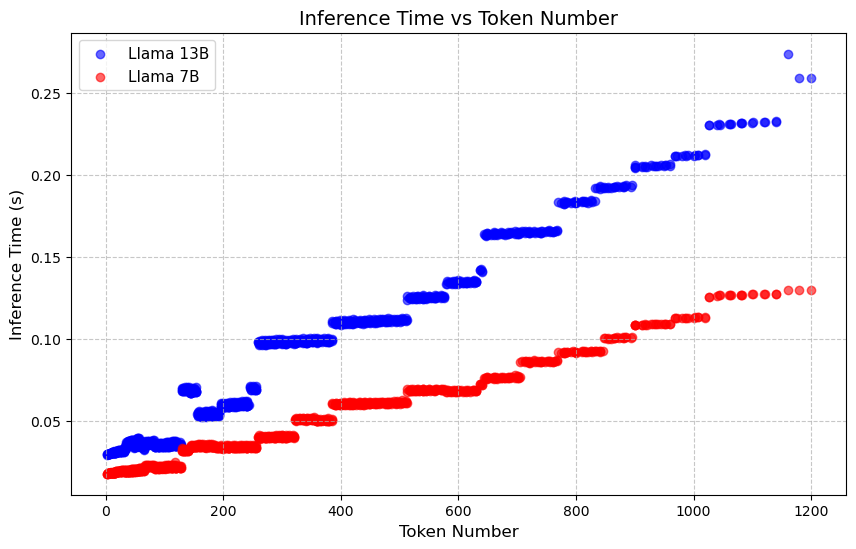

In [6]:
import matplotlib.pyplot as plt

# 假设你的 dataframe 叫 df1
# 计算 Batch Size * Sequence Length
df1['Batch_Size_x_Sequence'] = df1['Batch Size'] * df1['Sequence Length']
df2['Batch_Size_x_Sequence'] = df2['Batch Size'] * df2['Sequence Length']

# 创建散点图
plt.figure(figsize=(10, 6))  # 设置图形大小
plt.scatter(df1['Batch_Size_x_Sequence'], df1['Average Inference Time (s)'], 
           c='blue',  # 设置点颜色
           alpha=0.6,
           label='Llama 13B'  # 添加标签
           )  # 设置透明度
plt.scatter(df2['Batch_Size_x_Sequence'], df2['Average Inference Time (s)'],
            c='red',  # 设置点颜色
           alpha=0.6
            , label='Llama 7B'  # 添加标签
           )  # 设置透明度

# 设置标签和标题
plt.xlabel('Token Number')
plt.ylabel('Inference Time (s)')
plt.title('Inference Time vs Token Number')
# 添加图例
plt.legend()

# 添加网格（可选）
plt.grid(True, linestyle='--', alpha=0.7)

# 显示图形
plt.show()

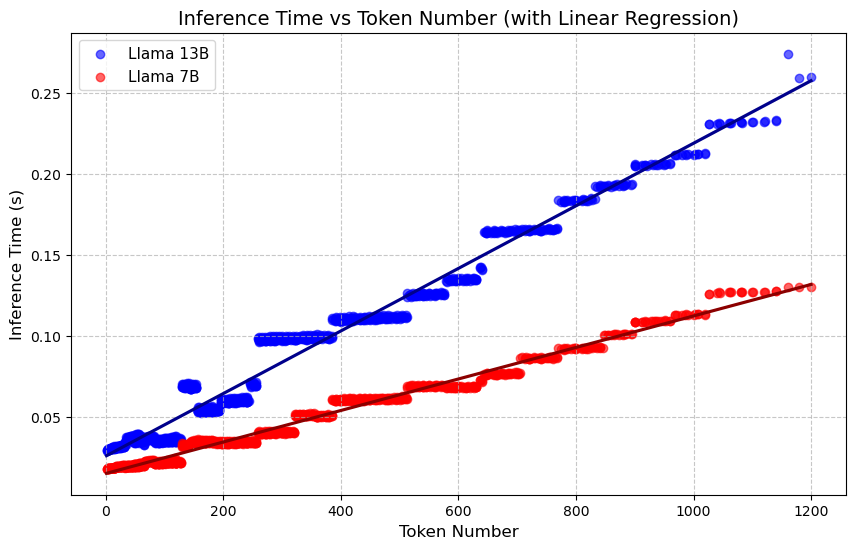

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # 假设你的数据在 pandas DataFrame 中

# --- 假设你的 DataFrame 叫 df1 和 df2 ---
# 假设 df1 和 df2 已经加载并包含以下列：
# 'Batch Size', 'Sequence Length', 'Average Inference Time (s)'

# 计算 Batch Size * Sequence Length
df1['Token Number'] = df1['Batch Size'] * df1['Sequence Length']
df2['Token Number'] = df2['Batch Size'] * df2['Sequence Length']

# --- 使用 Seaborn 绘制带回归线的散点图 ---
plt.figure(figsize=(10, 6)) # 设置图形大小

# 绘制 Llama 13B 的数据和回归线
sns.regplot(x='Token Number', y='Average Inference Time (s)', data=df1,
            scatter_kws={'alpha':0.6, 'color':'blue'}, # 设置散点图点属性
            line_kws={'color':'darkblue'},          # 设置回归线属性
            label='Llama 13B')                      # 添加标签

# 绘制 Llama 7B 的数据和回归线
sns.regplot(x='Token Number', y='Average Inference Time (s)', data=df2,
            scatter_kws={'alpha':0.6, 'color':'red'},  # 设置散点图点属性
            line_kws={'color':'darkred'},           # 设置回归线属性
            label='Llama 7B')                       # 添加标签

# 设置标签和标题
plt.xlabel('Token Number')
plt.ylabel('Inference Time (s)')
plt.title('Inference Time vs Token Number (with Linear Regression)')

# 添加图例
plt.legend()

# 添加网格（可选）
plt.grid(True, linestyle='--', alpha=0.7)

# 显示图形
plt.show()

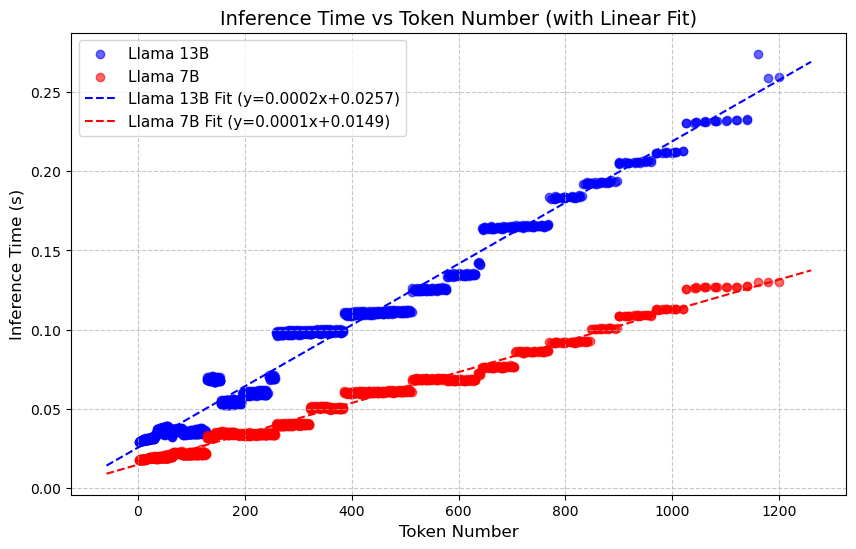

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # 假设你的数据在 pandas DataFrame 中

# --- 假设你的 DataFrame 叫 df1 和 df2 ---
# ... (计算 Token Number 的代码同上) ...

# --- 手动计算和绘制回归线 ---

# 对 Llama 13B 计算回归线参数 (斜率 m, 截距 b)
m1, b1 = np.polyfit(df1['Token Number'], df1['Average Inference Time (s)'], 1)
# 对 Llama 7B 计算回归线参数
m2, b2 = np.polyfit(df2['Token Number'], df2['Average Inference Time (s)'], 1)

# 创建散点图
plt.figure(figsize=(10, 6))
plt.scatter(df1['Token Number'], df1['Average Inference Time (s)'], c='blue', alpha=0.6, label='Llama 13B')
plt.scatter(df2['Token Number'], df2['Average Inference Time (s)'], c='red', alpha=0.6, label='Llama 7B')

# 生成回归线的 x 值范围 (可以根据你的数据范围调整)
x_values = np.array(plt.xlim()) # 获取当前 x 轴范围作为回归线绘制范围

# 绘制回归线
plt.plot(x_values, m1 * x_values + b1, color='blue', linestyle='--', label=f'Llama 13B Fit (y={m1:.4f}x+{b1:.4f})')
plt.plot(x_values, m2 * x_values + b2, color='red', linestyle='--', label=f'Llama 7B Fit (y={m2:.4f}x+{b2:.4f})')


# 设置标签和标题
plt.xlabel('Token Number')
plt.ylabel('Inference Time (s)')
plt.title('Inference Time vs Token Number (with Linear Fit)')

# 添加图例
plt.legend()

# 添加网格（可选）
plt.grid(True, linestyle='--', alpha=0.7)

# 显示图形
plt.show()

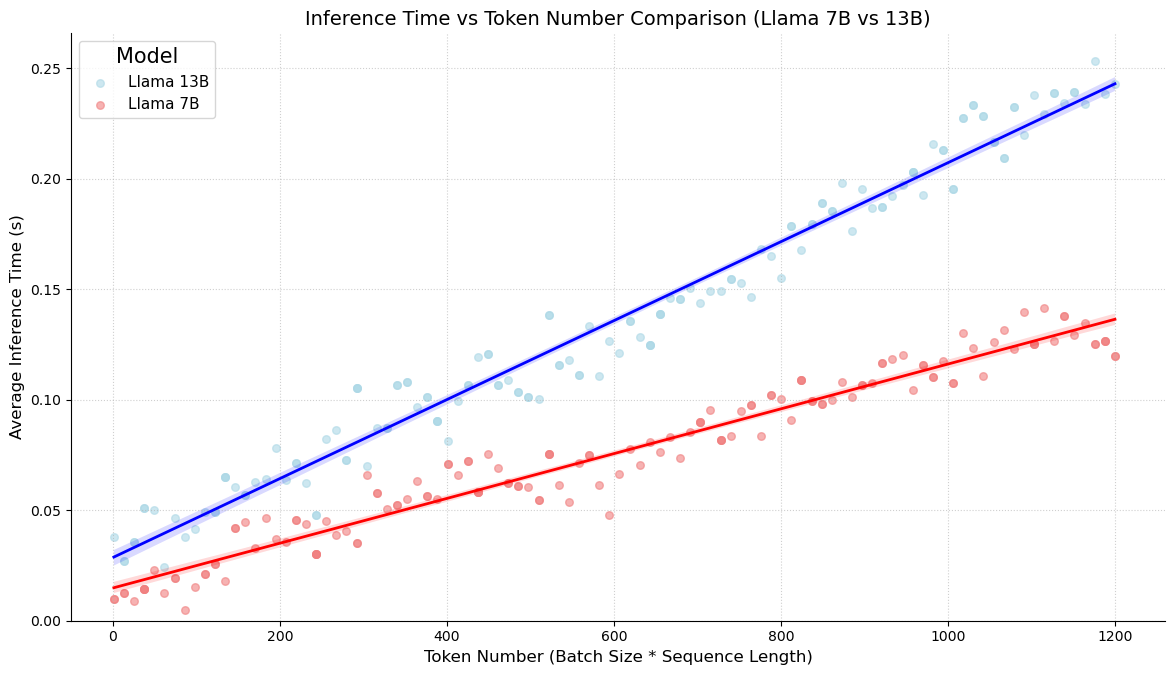

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # 假设你的数据在 pandas DataFrame 中
import numpy as np # 假设需要生成示例数据

# --- 假设你的 DataFrame 叫 df1 和 df2 ---
# 为了演示，我们生成一些示例数据
np.random.seed(0) # for reproducibility
token_numbers = np.linspace(1, 1200, 100)
# Llama 13B data (higher inference time)
inference_time_13b = 0.02 + 0.00018 * token_numbers + np.random.normal(0, 0.01, 100) + np.abs(np.sin(token_numbers/200)*0.01)
df1 = pd.DataFrame({
    'Token Number': token_numbers,
    'Average Inference Time (s)': np.clip(inference_time_13b, 0.01, None) # Ensure positive time
    # Add dummy Batch Size/Sequence Length if needed, though not used directly here
    # 'Batch Size': np.ones(100),
    # 'Sequence Length': token_numbers
})
# Repeat some token numbers to mimic the original plot's density
df1 = pd.concat([df1, df1.sample(50, replace=True)], ignore_index=True)


# Llama 7B data (lower inference time)
inference_time_7b = 0.01 + 0.00010 * token_numbers + np.random.normal(0, 0.008, 100) + np.abs(np.sin(token_numbers/200)*0.008)
df2 = pd.DataFrame({
    'Token Number': token_numbers,
    'Average Inference Time (s)': np.clip(inference_time_7b, 0.005, None) # Ensure positive time
    # 'Batch Size': np.ones(100),
    # 'Sequence Length': token_numbers
})
df2 = pd.concat([df2, df2.sample(50, replace=True)], ignore_index=True)


# --- 使用 Seaborn 绘制带回归线的散点图 ---
plt.figure(figsize=(12, 7)) # 可以稍微调整画布大小

# 绘制 Llama 13B 的数据和回归线
sns.regplot(x='Token Number', y='Average Inference Time (s)', data=df1,
            scatter_kws={'alpha': 0.6,       # 透明度
                         'color': 'lightblue', # 散点颜色：浅蓝色
                         's': 30},           # 散点大小 (可以调整这个数值)
            line_kws={'color': 'blue',       # 回归线颜色：蓝色
                      'linewidth': 2},      # 可以适当加粗回归线
            label='Llama 13B')

# 绘制 Llama 7B 的数据和回归线
sns.regplot(x='Token Number', y='Average Inference Time (s)', data=df2,
            scatter_kws={'alpha': 0.6,         # 透明度
                         'color': 'lightcoral', # 散点颜色：浅红色 (lightcoral 是一个不错的选择)
                         's': 30},             # 散点大小 (与上面保持一致)
            line_kws={'color': 'red',         # 回归线颜色：红色
                      'linewidth': 2},        # 可以适当加粗回归线
            label='Llama 7B')

# --- 美化 ---
# 设置更清晰的标签和标题字体大小
plt.xlabel('Token Number (Batch Size * Sequence Length)', fontsize=12)
plt.ylabel('Average Inference Time (s)', fontsize=12)
plt.title('Inference Time vs Token Number Comparison (Llama 7B vs 13B)', fontsize=14)

# 优化图例
plt.legend(fontsize=11, title='Model') # 可以给图例加个标题

# 优化网格线
plt.grid(True, linestyle=':', alpha=0.6) # 用点状线 ':' 可能更柔和

# 可以稍微调整坐标轴范围，让图形留白更舒服一点（可选）
plt.xlim(left= -50) # x轴左边留一点空间
plt.ylim(bottom=0) # y轴从0开始

# 提高刻度标签的可读性
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# 移除图形顶部和右部的边框（可选，有时更简洁）
sns.despine()

# 显示图形
plt.tight_layout() # 自动调整布局防止标签重叠
plt.show()

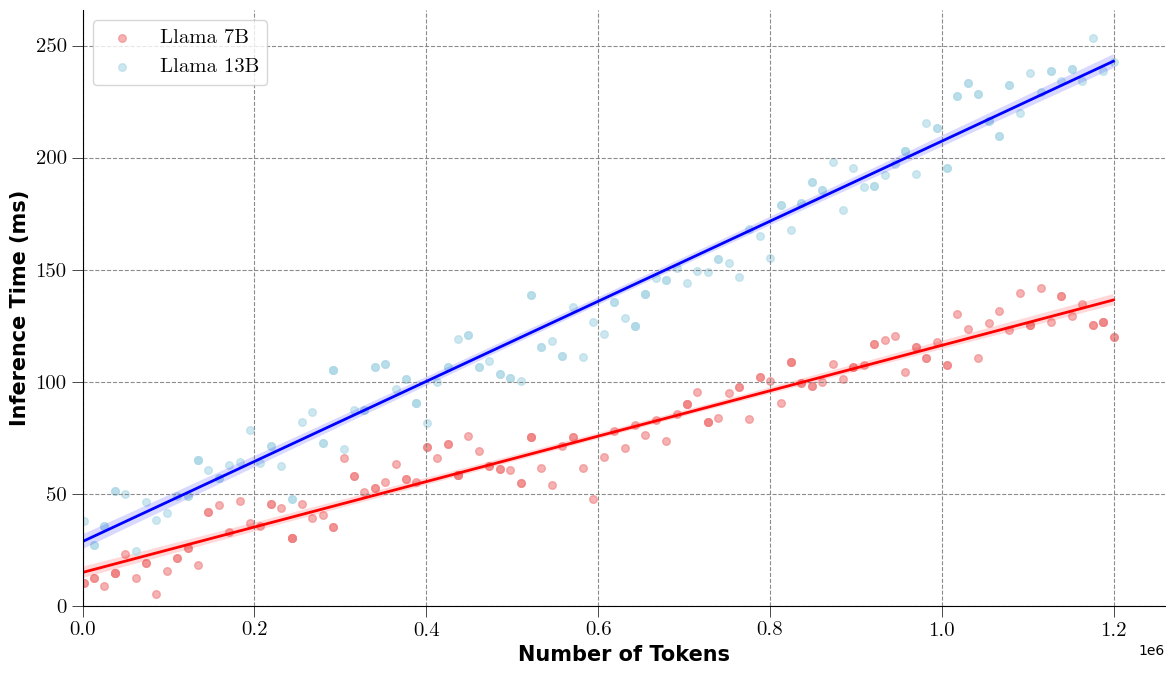

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm

# # --- 示例数据生成 ---
# np.random.seed(0)  # for reproducibility
# token_numbers = np.linspace(1, 1200, 100)
# # Llama 13B data (higher inference time)
# inference_time_13b = 0.02 + 0.00018 * token_numbers + np.random.normal(0, 0.01, 100) + np.abs(np.sin(token_numbers/200)*0.01)
# df1 = pd.DataFrame({
#     'Token Number': token_numbers,
#     'Average Inference Time (s)': np.clip(inference_time_13b, 0.01, None)  # Ensure positive time
# })
# df1 = pd.concat([df1, df1.sample(50, replace=True)], ignore_index=True)

# # Llama 7B data (lower inference time)
# inference_time_7b = 0.01 + 0.00010 * token_numbers + np.random.normal(0, 0.008, 100) + np.abs(np.sin(token_numbers/200)*0.008)
# df2 = pd.DataFrame({
#     'Token Number': token_numbers,
#     'Average Inference Time (s)': np.clip(inference_time_7b, 0.005, None)  # Ensure positive time
# })
# df2 = pd.concat([df2, df2.sample(50, replace=True)], ignore_index=True)

# --- 设置 CMU Serif 字体 ---
font_path = "/Users/luogan/Library/Fonts/CMU Serif Roman.ttf"  # Adjust this path if needed
font_prop = fm.FontProperties(fname=font_path)

# 设置全局样式
plt.rcParams.update({
    'font.size': 15,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.titlesize': 14,
    'figure.figsize': (12, 7)
})

# --- 使用 Seaborn 绘制带回归线的散点图 ---
plt.figure(figsize=(12, 7))

# 绘制 Llama 7B 的数据和回归线
sns.regplot(x='Token Number', y='Average Inference Time (s)', data=df2*1000,
            scatter_kws={'alpha': 0.6, 'color': 'lightcoral', 's': 30},
            line_kws={'color': 'red', 'linewidth': 2},
            label='Llama 7B')

# 绘制 Llama 13B 的数据和回归线
sns.regplot(x='Token Number', y='Average Inference Time (s)', data=df1*1000,
            scatter_kws={'alpha': 0.6, 'color': 'lightblue', 's': 30},
            line_kws={'color': 'blue', 'linewidth': 2},
            label='Llama 13B')

# --- 美化 ---
plt.xlabel('Number of Tokens', fontsize=15, weight='bold')
plt.ylabel('Inference Time (ms)', fontsize=15, weight='bold')

# 优化图例
plt.legend(prop=font_prop)

# 优化网格线
plt.grid(True, linestyle='--', alpha=0.9, color='gray')

# 调整坐标轴范围
plt.xlim(left=-50)
plt.ylim(bottom=0)

# 设置刻度标签字体
plt.xticks(fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)

# 移除顶部和右侧边框
sns.despine()

# 设置刻度线向外延伸（参考代码2）
plt.tick_params(axis='both', which='major', direction='out', length=8, width=0.5)

# 显示图形
plt.tight_layout()
plt.savefig('inference_time_comparison.pdf', bbox_inches='tight')  # 保存为 PDF 文件
plt.show()